In [9]:
import json as _json
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import maup
warnings.filterwarnings('ignore')

# load column names saved by cleaning.ipynb
with open('config.json') as _f:
    _cfg = _json.load(_f)
DEM_COL_1 = _cfg['DEM_COL_1']
REP_COL_1 = _cfg['REP_COL_1']
DEM_COL_2 = _cfg['DEM_COL_2']
REP_COL_2 = _cfg['REP_COL_2']
print('Loaded config:', _cfg)


Loaded config: {'DEM_COL_1': 'G24PREDHAR', 'REP_COL_1': 'G24PRERTRU', 'DEM_COL_2': 'G24USSDWAR', 'REP_COL_2': 'G24USSRDEA'}


In [2]:
# gerrychain imports
import networkx as nx
import gerrychain
from gerrychain import Graph, GeographicPartition, constraints, MarkovChain, Election
from gerrychain.updaters import cut_edges, Tally
from gerrychain.proposals import recom
from gerrychain.accept import always_accept
from functools import partial
from gerrychain.constraints import contiguous

In [3]:
# build graph and initial partition
ma_graph = Graph.from_file(r"MA\MA.shp", adjacency = "queen",
    cols_to_add = ["TOTPOP", "CD", DEM_COL_1, REP_COL_1, DEM_COL_2, REP_COL_2])

print("Is graph connected?", nx.is_connected(ma_graph))
print("Number of nodes:", len(ma_graph.nodes()))
print("Number of edges:", len(ma_graph.edges()))

tot_pop = sum([ma_graph.nodes()[v]["TOTPOP"] for v in ma_graph.nodes()])
num_dist = len(set([ma_graph.nodes()[v]["CD"] for v in ma_graph.nodes()]))

ideal_pop = tot_pop / num_dist
pop_tolerance = 0.02

initial_plan = {v: ma_graph.nodes()[v]["CD"] for v in ma_graph.nodes()}

elections = [
    Election("PRES24", {"Democratic": DEM_COL_1, "Republican": REP_COL_1}),
    Election("SEN24",  {"Democratic": DEM_COL_2, "Republican": REP_COL_2}),
]

my_updaters = {
    "cut_edges": cut_edges,
    "district population": Tally("TOTPOP", alias = "district population"),
}
my_updaters.update({election.name: election for election in elections})

initial_partition = GeographicPartition(
    ma_graph,
    assignment = initial_plan,
    updaters = my_updaters
)

print("initial partition contiguous?", contiguous(initial_partition))

for d in sorted(set(initial_plan.values())):
    verts_in_dist = [v for v in ma_graph.nodes() if initial_plan[v] == d]
    district = nx.subgraph(ma_graph, verts_in_dist)
    print("district", d, "connected?", nx.is_connected(district), "components:", nx.number_connected_components(district))

C:\Users\anton\anaconda3\envs\gerry\Lib\site-packages\gerrychain\graph\graph.py:406: UserWarning: Found islands (degree-0 nodes). Indices of islands: {924, 1447}
  warnings.warn(


Is graph connected? False
Number of nodes: 2383
Number of edges: 6986
initial partition contiguous? False
district 01 connected? True components: 1
district 02 connected? True components: 1
district 03 connected? True components: 1
district 04 connected? True components: 1
district 05 connected? True components: 1
district 06 connected? True components: 1
district 07 connected? False components: 2
district 08 connected? False components: 4
district 09 connected? False components: 4


district 07
district 08
district 09
{'boundary_node': False, 'area': 4517305.493465681, 'UNIQUE_ID': 'Abington Pct 1', 'COUNTYFP': 23, 'City/Town': 'Abington', 'Ward': '-', 'Pct': '1', 'County': 'Plymouth', 'CONG_DIST': '08', 'SLDL_DIST': 'P07', 'SLDU_DIST': 'NRP', 'G24PREDHAR': 1019, 'G24PRELOLI': 12, 'G24PREOOTH': 6, 'G24PRERTRU': 905, 'G24PREUAYY': 19, 'G24PREUCRU': 5, 'G24PREUSON': 0, 'G24PREUSTE': 15, 'G24PREUWES': 0, 'G24USSDWAR': 948, 'G24USSOOTH': 0, 'G24USSRDEA': 1012, 'GCON01DNEA': 0, 'GCON01OOTH': 0, 'GCON01UMIL': 0, 'GCON02DMCG': 0, 'GCON02OOTH': 0, 'GCON02USHE': 0, 'GCON03DTRA': 0, 'GCON03OOTH': 0, 'GCON04DAUC': 0, 'GCON04OOTH': 0, 'GCON04UFAD': 0, 'GCON05DCLA': 0, 'GCON05OOTH': 0, 'GCON06DMOU': 0, 'GCON06OOTH': 0, 'GCON07DPRE': 0, 'GCON07OOTH': 0, 'GCON08DLYN': 1179, 'GCON08OOTH': 1, 'GCON08RBUR': 739, 'GCON09DKEA': 0, 'GCON09OOTH': 0, 'GCON09RSUL': 0, 'GSLB01DLOU': 0, 'GSLB01OOTH': 0, 'GSLB01RCHA': 0, 'GSLB02DHAW': 0, 'GSLB02OOTH': 0, 'GSLB02UBEL': 0, 'GSLB02WNEL': 0, 'G

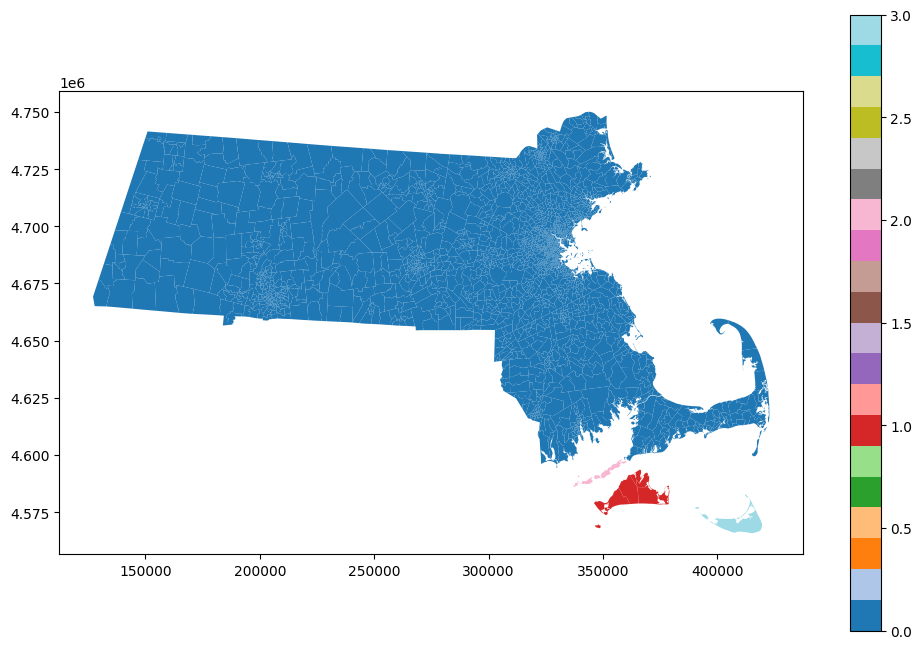

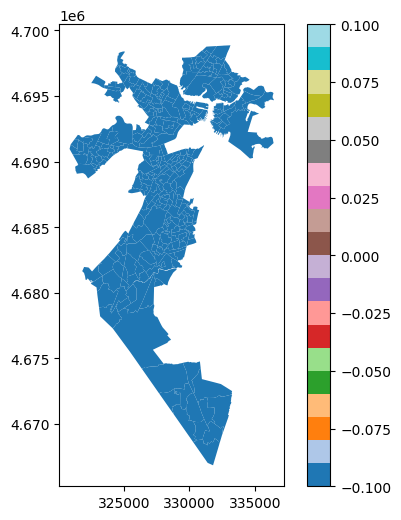

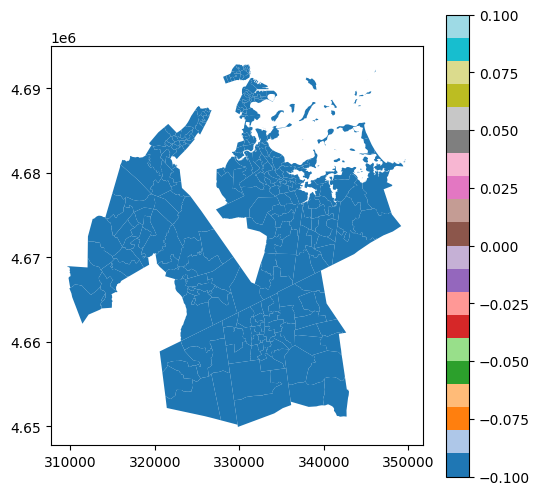

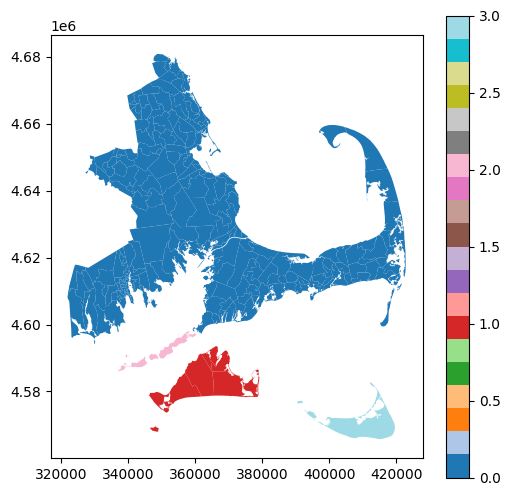

In [4]:
# optional map check to see disconnected pieces
df = gpd.read_file(r"MA\MA.shp")
df.index = list(ma_graph.nodes())

comp_id = {}
for i, comp in enumerate(nx.connected_components(ma_graph)):
    for v in comp:
        comp_id[v] = i

df["component"] = pd.Series(comp_id)

df.plot(column = "component", cmap = "tab20", figsize = (12,8), legend = True)

for d in ["07", "08", "09"]:
    df[df["CD"] == d].plot(column = "component", cmap = "tab20", figsize = (6,6), legend = True)
    print("district", d)

print(ma_graph.nodes[list(ma_graph.nodes())[0]])

In [5]:
# patch the graph by connecting the nearest disconnected pieces inside each district
temp_graph = nx.Graph(ma_graph)
centroids = df.geometry.centroid
added_edges = []  # track every edge we manually add

for d in sorted(set(initial_plan.values())):
    verts_in_dist = [v for v in temp_graph.nodes() if initial_plan[v] == d]
    district = nx.subgraph(temp_graph, verts_in_dist)

    while not nx.is_connected(district):
        comps = sorted(nx.connected_components(district), key=len, reverse=True)
        main_comp = list(comps[0])
        other_comp = list(comps[1])

        best_u = None
        best_v = None
        best_dist = float("inf")

        for u in main_comp:
            for v in other_comp:
                dist = centroids.loc[u].distance(centroids.loc[v])
                if dist < best_dist:
                    best_dist = dist
                    best_u = u
                    best_v = v

        temp_graph.add_edge(best_u, best_v)
        added_edges.append((best_u, best_v, d, round(best_dist, 2)))
        print("added edge in district", d, "between", best_u, "and", best_v, "distance", round(best_dist, 2))

        district = nx.subgraph(temp_graph, verts_in_dist)

ma_graph = gerrychain.Graph(temp_graph)

initial_partition = GeographicPartition(
    ma_graph,
    assignment=initial_plan,
    updaters=my_updaters
)

print("graph connected now?", nx.is_connected(ma_graph))
print("initial partition contiguous now?", contiguous(initial_partition))


added edge in district 07 between 629 and 199 distance 648.58
added edge in district 08 between 1701 and 264 distance 1210.47
added edge in district 08 between 427 and 385 distance 1310.3
added edge in district 08 between 436 and 191 distance 4343.66
added edge in district 09 between 830 and 2064 distance 10714.75
added edge in district 09 between 669 and 924 distance 13653.45
added edge in district 09 between 773 and 1447 distance 40816.46
graph connected now? True
initial partition contiguous now? True


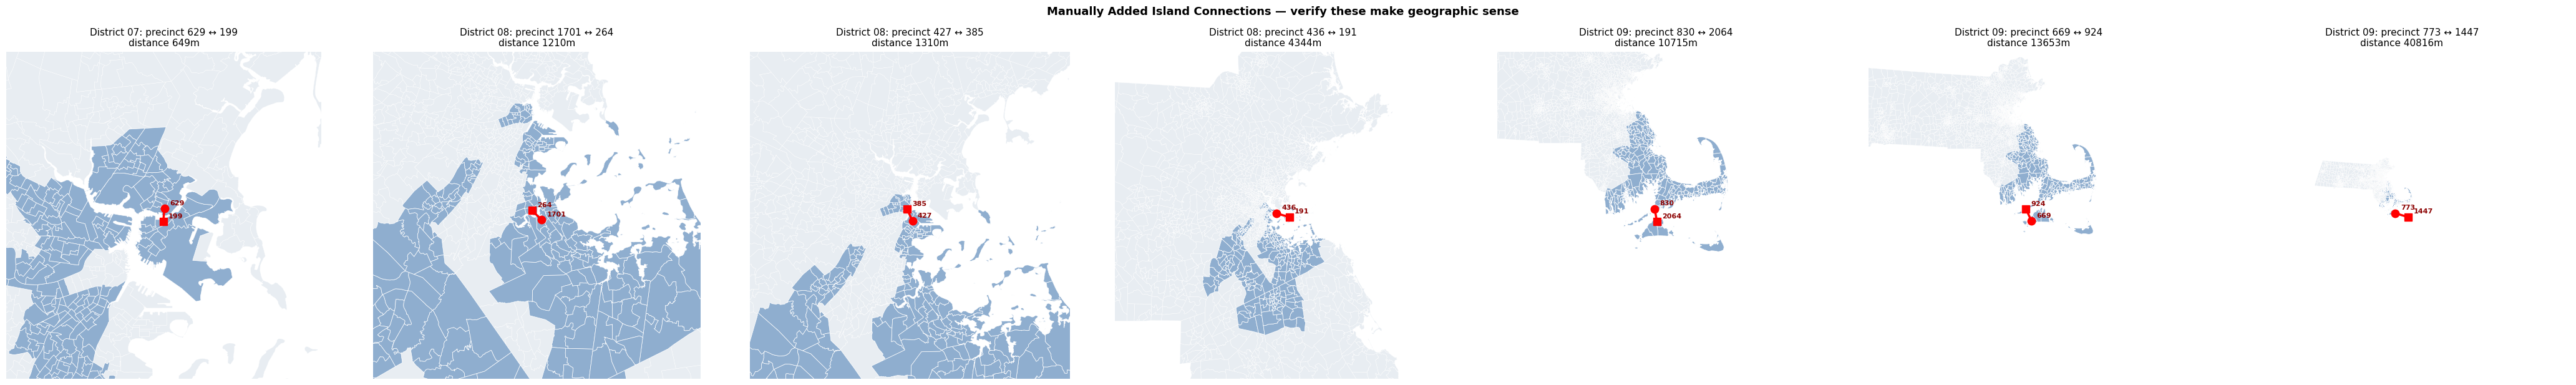


To remove a connection: go to Cell 12, comment out the iteration that added it.
To add a custom connection: add temp_graph.add_edge(A, B) at the end of Cell 12
  before ma_graph = gerrychain.Graph(temp_graph)

All added edges:
  District 07: 629 <-> 199  (648.58m)
  District 08: 1701 <-> 264  (1210.47m)
  District 08: 427 <-> 385  (1310.3m)
  District 08: 436 <-> 191  (4343.66m)
  District 09: 830 <-> 2064  (10714.75m)
  District 09: 669 <-> 924  (13653.45m)
  District 09: 773 <-> 1447  (40816.46m)


In [6]:
# dual graph visualization of manually added island connections
# inspect these visually and manually add/remove connections in Cell 12 if needed
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, len(added_edges), figsize=(6 * len(added_edges), 6))
if len(added_edges) == 1:
    axes = [axes]

for ax, (u, v, d, dist) in zip(axes, added_edges):
    # show the full district
    district_df = df[df["CD"] == d]
    df.plot(ax=ax, color="#E8EDF2", edgecolor="white", linewidth=0.3)
    district_df.plot(ax=ax, color="#8FAECF", edgecolor="white", linewidth=0.5)

    # draw the added edge as a red line between centroids
    cu, cv = centroids.loc[u], centroids.loc[v]
    ax.plot([cu.x, cv.x], [cu.y, cv.y], 'r-', linewidth=2.5, zorder=5)
    ax.plot(cu.x, cu.y, 'ro', markersize=9, zorder=6)
    ax.plot(cv.x, cv.y, 'rs', markersize=9, zorder=6)
    ax.annotate(str(u), (cu.x, cu.y), textcoords="offset points", xytext=(6,4),
                fontsize=8, color='darkred', fontweight='bold')
    ax.annotate(str(v), (cv.x, cv.y), textcoords="offset points", xytext=(6,4),
                fontsize=8, color='darkred', fontweight='bold')

    # zoom into the area of interest
    pad = dist * 12
    ax.set_xlim(min(cu.x, cv.x) - pad, max(cu.x, cv.x) + pad)
    ax.set_ylim(min(cu.y, cv.y) - pad, max(cu.y, cv.y) + pad)
    ax.set_title(f"District {d}: precinct {u} ↔ {v}\ndistance {dist:.0f}m", fontsize=11)
    ax.set_axis_off()

plt.suptitle("Manually Added Island Connections — verify these make geographic sense",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("island_connections.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTo remove a connection: go to Cell 12, comment out the iteration that added it.")
print("To add a custom connection: add temp_graph.add_edge(A, B) at the end of Cell 12")
print("  before ma_graph = gerrychain.Graph(temp_graph)")
print("\nAll added edges:")
for u, v, d, dist in added_edges:
    print(f"  District {d}: {u} <-> {v}  ({dist}m)")


In [7]:
def efficiency_gap(partition, election_key):
    results = partition[election_key]
    total_votes = 0
    wasted_dem = 0
    wasted_rep = 0
    dem_votes = results.votes("Democratic")
    rep_votes = results.votes("Republican")
    for i in range(len(dem_votes)):
        d_votes = dem_votes[i]
        r_votes = rep_votes[i]
        total = d_votes + r_votes
        total_votes += total
        threshold = total / 2 + 1
        if d_votes > r_votes:
            wasted_dem += d_votes - threshold
            wasted_rep += r_votes
        else:
            wasted_rep += r_votes - threshold
            wasted_dem += d_votes
    return (wasted_dem - wasted_rep) / total_votes

rw_proposal = partial(
    recom,
    pop_col = "TOTPOP",
    pop_target = ideal_pop,
    epsilon = pop_tolerance,
    node_repeats = 2
)

population_constraint = constraints.within_percent_of_ideal_population(
    initial_partition,
    pop_tolerance,
    pop_key = "district population"
)

compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2 * len(initial_partition["cut_edges"])
)

# --- Ensemble 1: 2024 Presidential ---
chain1 = MarkovChain(
    proposal = rw_proposal,
    constraints = [population_constraint, compactness_bound],
    accept = always_accept,
    initial_state = initial_partition,
    total_steps = 20000
)

eg1, dem_won1, cutedges1, margins1 = [], [], [], []

for part in chain1.with_progress_bar():
    cutedges1.append(len(part["cut_edges"]))
    dem_won1.append(part["PRES24"].wins("Democratic"))
    eg1.append(efficiency_gap(part, "PRES24"))
    margins1.append(sorted(part["PRES24"].percents("Democratic")))

print("Ensemble 1 done")

# --- Ensemble 2: 2024 US Senate ---
chain2 = MarkovChain(
    proposal = rw_proposal,
    constraints = [population_constraint, compactness_bound],
    accept = always_accept,
    initial_state = initial_partition,
    total_steps = 20000
)

eg2, dem_won2, cutedges2, margins2 = [], [], [], []

for part in chain2.with_progress_bar():
    cutedges2.append(len(part["cut_edges"]))
    dem_won2.append(part["SEN24"].wins("Democratic"))
    eg2.append(efficiency_gap(part, "SEN24"))
    margins2.append(sorted(part["SEN24"].percents("Democratic")))

print("Ensemble 2 done")

C:\Users\anton\anaconda3\envs\gerry\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|████████████████████████████████| 20000/20000 [56:45<00:00,  5.87it/s]


Ensemble 1 done


100%|████████████████████████████████| 20000/20000 [57:32<00:00,  5.79it/s]

Ensemble 2 done


In [10]:
# final summary
print("FINAL SUMMARY")
print("graph connected:", nx.is_connected(ma_graph))
print("initial partition contiguous:", contiguous(initial_partition))
print("district count:", len(initial_partition.parts))
print("total population:", sum(initial_partition["district population"].values()))

FINAL SUMMARY
graph connected: True
initial partition contiguous: True
district count: 9
total population: 7029917


In [11]:
import matplotlib.pyplot as plt

# actual MA map values
actual_cutedges = len(initial_partition["cut_edges"])
actual_dem_won1 = initial_partition["PRES24"].wins("Democratic")
actual_eg1 = efficiency_gap(initial_partition, "PRES24")
actual_dem_won2 = initial_partition["SEN24"].wins("Democratic")
actual_eg2 = efficiency_gap(initial_partition, "SEN24")
actual_margins1 = sorted(initial_partition["PRES24"].percents("Democratic"))
actual_margins2 = sorted(initial_partition["SEN24"].percents("Democratic"))

print("actual cut edges:", actual_cutedges)
print("actual dem won (pres):", actual_dem_won1, "| actual EG (pres):", round(actual_eg1, 4))
print("actual dem won (senate):", actual_dem_won2, "| actual EG (senate):", round(actual_eg2, 4))

actual cut edges: 659
actual dem won (pres): 9 | actual EG (pres): -0.2409
actual dem won (senate): 9 | actual EG (senate): -0.3015


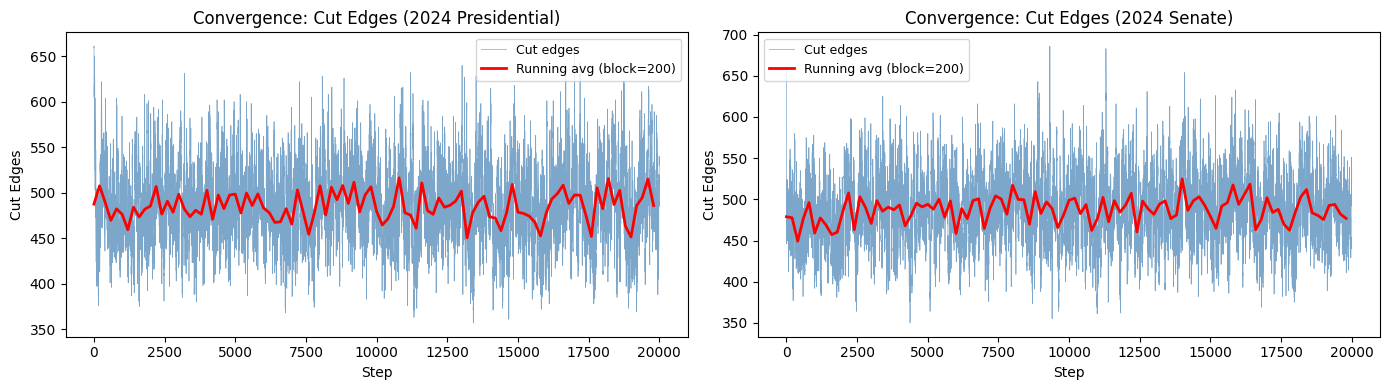

In [12]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

block_size = max(1, len(cutedges1) // 100)  # 1 block = 1% of total steps

def block_running_avg(data, block_size):
    xs = list(range(0, len(data), block_size))
    ys = [sum(data[i:i+block_size]) / len(data[i:i+block_size]) for i in xs]
    # repeat each y value block_size times to make a step function
    xs_step = [x for x in xs for _ in range(block_size)][:len(data)]
    ys_step = [y for y in ys for _ in range(block_size)][:len(data)]
    return xs_step, ys_step

xs1, ys1 = block_running_avg(cutedges1, block_size)
xs2, ys2 = block_running_avg(cutedges2, block_size)

axes[0].plot(cutedges1, linewidth=0.5, color='steelblue', alpha=0.7, label='Cut edges')
axes[0].plot(xs1, ys1, color='red', linewidth=2, label=f'Running avg (block={block_size})')
axes[0].set_title("Convergence: Cut Edges (2024 Presidential)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Cut Edges")
axes[0].legend(fontsize=9)

axes[1].plot(cutedges2, linewidth=0.5, color='steelblue', alpha=0.7, label='Cut edges')
axes[1].plot(xs2, ys2, color='red', linewidth=2, label=f'Running avg (block={block_size})')
axes[1].set_title("Convergence: Cut Edges (2024 Senate)")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cut Edges")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("convergence.png", dpi=150)
plt.show()


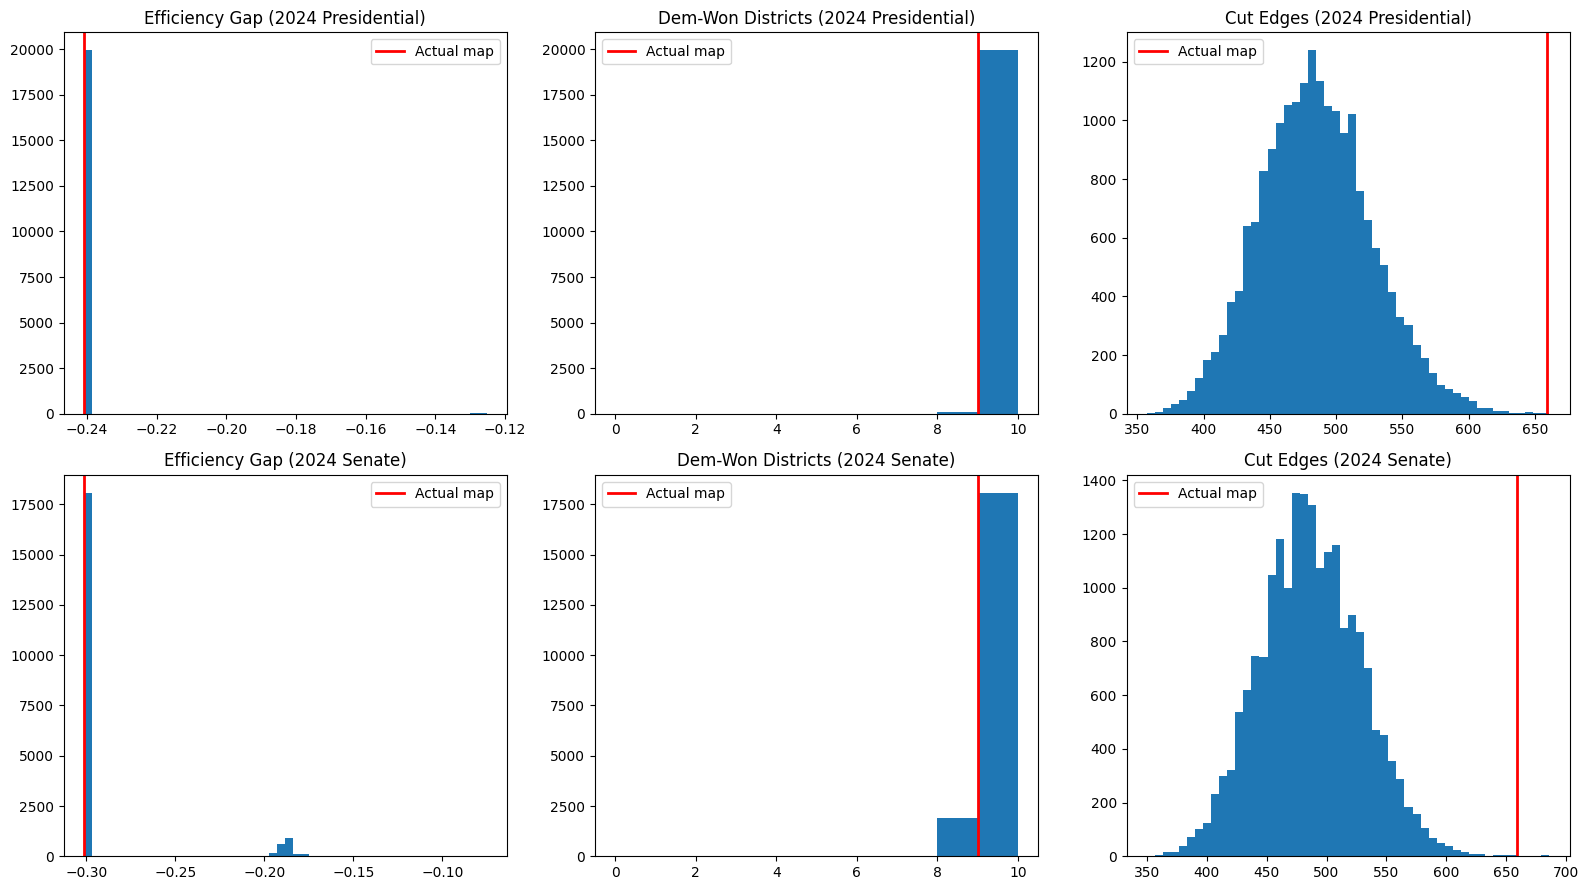

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: 2024 Presidential
axes[0][0].hist(eg1, bins=50)
axes[0][0].axvline(actual_eg1, color='red', linewidth=2, label='Actual map')
axes[0][0].set_title("Efficiency Gap (2024 Presidential)")
axes[0][0].legend()

axes[0][1].hist(dem_won1, bins=range(0, 11))
axes[0][1].axvline(actual_dem_won1, color='red', linewidth=2, label='Actual map')
axes[0][1].set_title("Dem-Won Districts (2024 Presidential)")
axes[0][1].legend()

axes[0][2].hist(cutedges1, bins=50)
axes[0][2].axvline(actual_cutedges, color='red', linewidth=2, label='Actual map')
axes[0][2].set_title("Cut Edges (2024 Presidential)")
axes[0][2].legend()

# Row 2: 2024 Senate
axes[1][0].hist(eg2, bins=50)
axes[1][0].axvline(actual_eg2, color='red', linewidth=2, label='Actual map')
axes[1][0].set_title("Efficiency Gap (2024 Senate)")
axes[1][0].legend()

axes[1][1].hist(dem_won2, bins=range(0, 11))
axes[1][1].axvline(actual_dem_won2, color='red', linewidth=2, label='Actual map')
axes[1][1].set_title("Dem-Won Districts (2024 Senate)")
axes[1][1].legend()

axes[1][2].hist(cutedges2, bins=50)
axes[1][2].axvline(actual_cutedges, color='red', linewidth=2, label='Actual map')
axes[1][2].set_title("Cut Edges (2024 Senate)")
axes[1][2].legend()

plt.tight_layout()
plt.savefig("histograms.png", dpi=150)
plt.show()

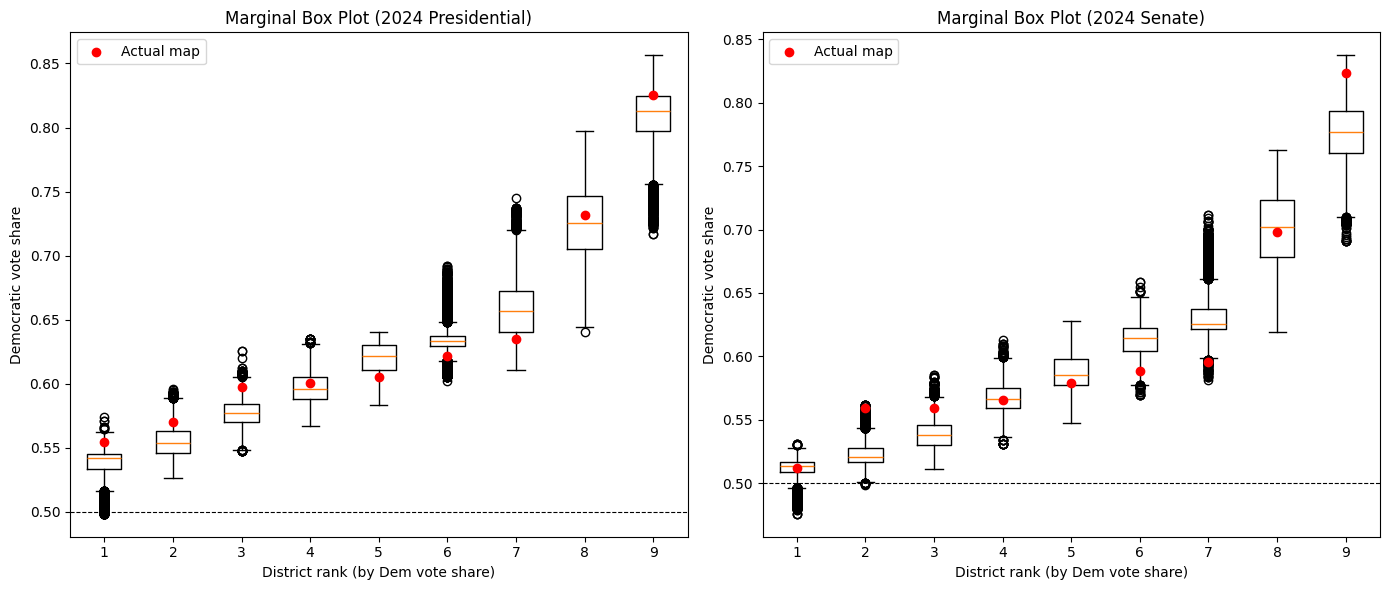

In [14]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
num_districts = len(actual_margins1)

# 2024 Presidential
box_data1 = [[margins1[step][d] for step in range(len(margins1))] for d in range(num_districts)]
axes[0].boxplot(box_data1, positions=range(1, num_districts + 1))
axes[0].scatter(range(1, num_districts + 1), actual_margins1, color='red', zorder=5, label='Actual map')
axes[0].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[0].set_title("Marginal Box Plot (2024 Presidential)")
axes[0].set_xlabel("District rank (by Dem vote share)")
axes[0].set_ylabel("Democratic vote share")
axes[0].legend()

# 2024 Senate
box_data2 = [[margins2[step][d] for step in range(len(margins2))] for d in range(num_districts)]
axes[1].boxplot(box_data2, positions=range(1, num_districts + 1))
axes[1].scatter(range(1, num_districts + 1), actual_margins2, color='red', zorder=5, label='Actual map')
axes[1].axhline(0.5, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Marginal Box Plot (2024 Senate)")
axes[1].set_xlabel("District rank (by Dem vote share)")
axes[1].set_ylabel("Democratic vote share")
axes[1].legend()

plt.tight_layout()
plt.savefig("marginal_boxplots.png", dpi=150)
plt.show()

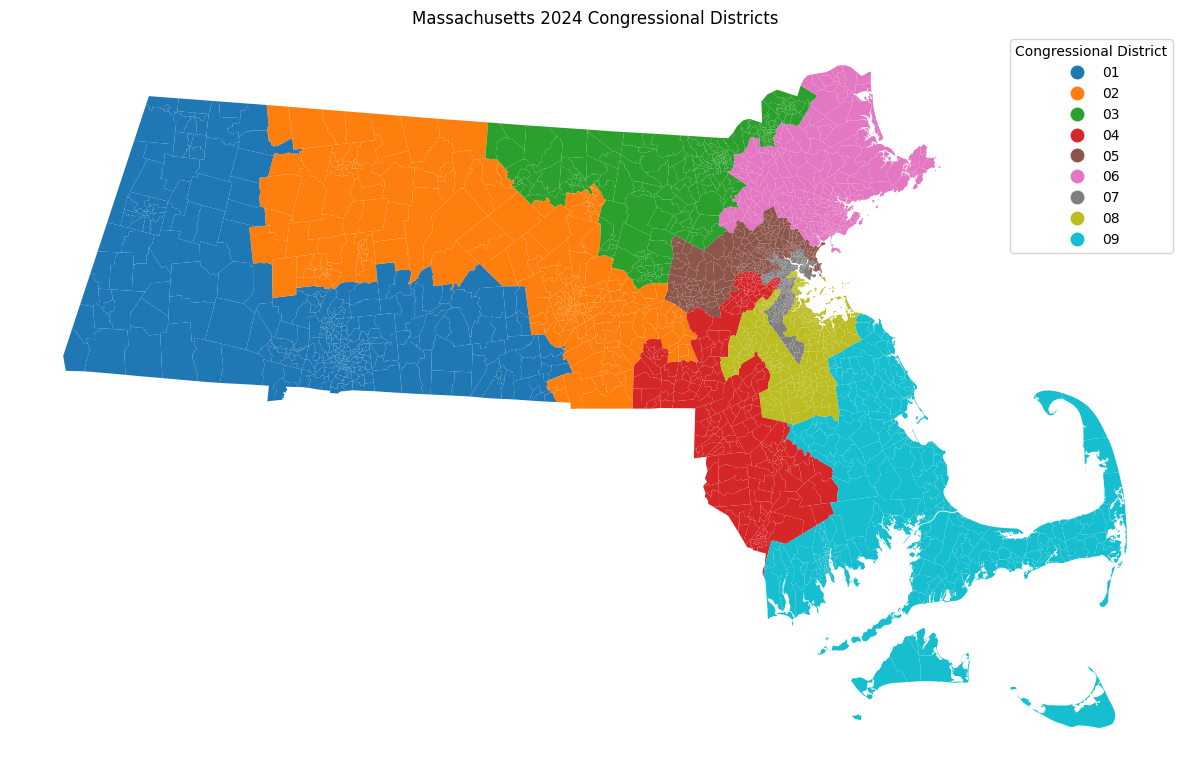

In [15]:
# plot the actual MA congressional district map
df_plot = gpd.read_file(r"MA\MA.shp")

fig, ax = plt.subplots(figsize=(12, 8))
df_plot.plot(column="CD", cmap="tab10", legend=True, ax=ax,
             legend_kwds={"title": "Congressional District"})
ax.set_title("Massachusetts 2024 Congressional Districts")
ax.set_axis_off()
plt.tight_layout()
plt.savefig("ma_districts_map.png", dpi=150)
plt.show()

In [16]:
from gerrychain.metrics import polsby_popper

# compute PP for the actual map
pp_scores = polsby_popper(initial_partition)
print("Polsby-Popper scores for actual MA map:")
for d in sorted(pp_scores):
    print(f"  District {d}: {pp_scores[d]:.4f}")
print(f"  Mean PP: {sum(pp_scores.values()) / len(pp_scores):.4f}")

Polsby-Popper scores for actual MA map:
  District 01: 0.2797
  District 02: 0.2119
  District 03: 0.2237
  District 04: 0.1703
  District 05: 0.1525
  District 06: 0.0421
  District 07: 0.0502
  District 08: 0.0474
  District 09: 0.0085
  Mean PP: 0.1318


100%|████████████████████████████████| 2000/2000 [2:32:03<00:00,  4.56s/it]


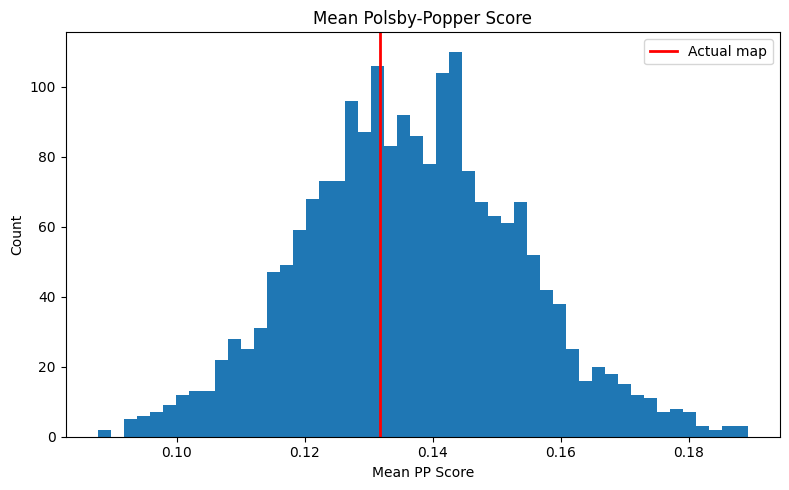

In [17]:
import numpy as np

chain_pp = MarkovChain(
    proposal=rw_proposal,
    constraints=[population_constraint, compactness_bound],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=2000
)

mean_pp_ensemble = []
for part in chain_pp.with_progress_bar():
    part_pp = []
    for d in part.parts:
        nodes = list(part.parts[d])
        geom = df_plot.loc[nodes, "geometry"].union_all()
        area = geom.area
        perimeter = geom.length
        part_pp.append((4 * np.pi * area) / (perimeter ** 2))
    mean_pp_ensemble.append(sum(part_pp) / len(part_pp))

actual_mean_pp = sum(pp_scores.values()) / len(pp_scores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(mean_pp_ensemble, bins=50)
ax.axvline(actual_mean_pp, color='red', linewidth=2, label='Actual map')
ax.set_title("Mean Polsby-Popper Score")
ax.set_xlabel("Mean PP Score")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("polsby_popper.png", dpi=150)
plt.show()